# Задача: Маршрутизация пациентов к врачу-специалисту средствами NLP

Проект по многоклассовой классификации медицинских обращений пациентов. Задача — по тексту вопроса пользователя автоматически определить, к какому врачу-специалисту его следует направить.

# 1. Подготовка

In [1]:
# сделаем все максимально детерминированным для воспроизводимости результатов

import os
import random
import numpy as np

seed = 42

os.environ["PYTHONHASHSEED"] = str(seed)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

random.seed(seed)
np.random.seed(seed)

import torch
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Для большей детерминированности
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from transformers import set_seed
set_seed(seed)

print(f"Seed fixed: {seed}")

Seed fixed: 42


In [2]:
# загружаем необходимые библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [3]:
# загружаем данные

train = pd.read_parquet('/Users/konstantingeneralov1/Data/train-00000-of-00001.parquet')
test = pd.read_parquet('/Users/konstantingeneralov1/Data/test-00000-of-00001.parquet')

nlp_train = train.copy()
nlp_test = test.copy()

summary_train = pd.DataFrame({
    'missing': nlp_train.isnull().sum(),
    'duplicated': nlp_train.duplicated().sum(),
    'unique': nlp_train.nunique(),
    'dtype': nlp_train.dtypes
})
summary_test = pd.DataFrame({
    'missing': nlp_test.isnull().sum(),
    'duplicated': nlp_test.duplicated().sum(),
    'unique': nlp_test.nunique(),
    'dtype': nlp_test.dtypes
})

display('train', summary_train, 'test', summary_test)

display(nlp_train.head(), nlp_test.head())

'train'

,missing,duplicated,unique,dtype
topic,0,0,39,object
user_question,0,0,3312,object
assistant_answer,0,0,3536,object
to_doctor,0,0,104,object
__index_level_0__,0,0,3546,int64
prompt,0,0,3536,object


'test'

,missing,duplicated,unique,dtype
topic,0,0,26,object
user_question,0,0,393,object
assistant_answer,0,0,395,object
to_doctor,0,0,50,object
__index_level_0__,0,0,395,int64
prompt,0,0,395,object


,topic,user_question,assistant_answer,to_doctor,__index_level_0__,prompt
0,лабораторные исследования,Я сдала анализ крови на сахар и показатели чут...,Повышение уровня сахара в крови может быть выз...,эндокринолог,3263,<s><|user|>Я сдала анализ крови на сахар и пок...
1,педиатрия,"Мой ребенок кашляет уже 3 дня, отхаркивается с...",Кашель у детей может быть вызван разными причи...,педиатр,518,"<s><|user|>Мой ребенок кашляет уже 3 дня, отха..."
2,проктология,Я заметил не очень приятного вида опухоль возл...,"Извините, я не могу ставить диагнозы. Анальные...",проктолог,1160,<s><|user|>Я заметил не очень приятного вида о...
3,эндокринология,У меня повышенный уровень сахара в крови. Врач...,Повышенный уровень сахара в крови - это действ...,эндокринолог,286,<s><|user|>У меня повышенный уровень сахара в ...
4,семейная медицина,У меня постоянно болит голова. Я уже несколько...,Головные боли могут быть вызваны множеством пр...,невролог,2132,<s><|user|>У меня постоянно болит голова. Я уж...


,topic,user_question,assistant_answer,to_doctor,__index_level_0__,prompt
0,дерматология,"У меня на руке появилась сыпь, которая чешется...",Сыпь на руках может быть вызвана разными причи...,дерматолог,1813,"<s><|user|>У меня на руке появилась сыпь, кото..."
1,травматология,У меня на ноге сильный отек после растяжения. ...,Отек после растяжения - это нормальная реакция...,травматолог,339,<s><|user|>У меня на ноге сильный отек после р...
2,нутрициология,"Я хочу похудеть, но не знаю с чего начать. Мож...","Чтобы составить индивидуальный план питания, м...",диетолог,464,"<s><|user|>Я хочу похудеть, но не знаю с чего ..."
3,андрология,"У меня болит живот, и у меня проблемы с потенц...",Боли в животе и проблемы с потенцией могут быт...,андролог,2050,"<s><|user|>У меня болит живот, и у меня пробле..."
4,офтальмология,"У меня покраснел белок глаза, и немного болит....",Покрасневшее белку глаза и боль могут быть при...,офтальмолог,2856,"<s><|user|>У меня покраснел белок глаза, и нем..."


Данные загружены из файлов .parquet (train и test). 
На этом этапе были проверены:
- наличие пропущенных значений
- дубликаты
- количество уникальных значений и типы столбцов
Данные не содержат пропусков и дубликатов, что позволяет перейти к очистке и нормализации без предварительного восстановления.

Для выполнения задачи берем следующие поля:

**Входные данные:** текст вопроса/жалобы пациента (`user_question`)

**Целевая переменная:** специальность врача (`to_doctor`)


Поля `assistant_answer` и `prompt` намеренно исключены из признаков. `assistant_answer` создаёт утечку данных — в реальном сценарии маршрутизации ответ ещё недоступен. `prompt` является техническим полем и не несёт информации о содержании жалобы.

# 2. Предобработка и Анализ

## 2.1 Очистка текста входных данных `user_question`

In [4]:
# проведем очистку текста от лишних символов и приведем к нижнему регистру

import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    # оставляем русские/латинские буквы и пробелы; всё остальное -> пробел
    text = re.sub(r"[^a-zа-яё\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

nlp_train["text_clean"] = nlp_train["user_question"].map(clean_text)
nlp_test["text_clean"] = nlp_test["user_question"].map(clean_text)

nlp_train[["user_question", "text_clean"]].head(5)

,user_question,text_clean
0,Я сдала анализ крови на сахар и показатели чут...,я сдала анализ крови на сахар и показатели чут...
1,"Мой ребенок кашляет уже 3 дня, отхаркивается с...",мой ребенок кашляет уже дня отхаркивается с тр...
2,Я заметил не очень приятного вида опухоль возл...,я заметил не очень приятного вида опухоль возл...
3,У меня повышенный уровень сахара в крови. Врач...,у меня повышенный уровень сахара в крови врач ...
4,У меня постоянно болит голова. Я уже несколько...,у меня постоянно болит голова я уже несколько ...


In [5]:
# токенизируем текст, для простоты используем базовый метод split, но в реальных задачах будем использовать встроенные токенизаторы от трансформеров

def word_tokenize(text: str) -> list[str]:  
    return text.split()

nlp_train["tokens"] = nlp_train["text_clean"].map(word_tokenize)

nlp_train[["text_clean", "tokens"]].head(5)

,text_clean,tokens
0,я сдала анализ крови на сахар и показатели чут...,"[я, сдала, анализ, крови, на, сахар, и, показа..."
1,мой ребенок кашляет уже дня отхаркивается с тр...,"[мой, ребенок, кашляет, уже, дня, отхаркиваетс..."
2,я заметил не очень приятного вида опухоль возл...,"[я, заметил, не, очень, приятного, вида, опухо..."
3,у меня повышенный уровень сахара в крови врач ...,"[у, меня, повышенный, уровень, сахара, в, кров..."
4,у меня постоянно болит голова я уже несколько ...,"[у, меня, постоянно, болит, голова, я, уже, не..."


In [6]:
# посчитаем длину текста в символах и словах

nlp_train["len_chars"] = nlp_train["text_clean"].str.len()
nlp_train["len_words"] = nlp_train["text_clean"].str.split().map(len)

nlp_train[["len_chars", "len_words"]].describe()

,len_chars,len_words
count,3546.000000,3546.000000
mean,96.148900,16.778060
std,36.291468,6.011328
min,25.000000,5.000000
25%,72.000000,13.000000
50%,90.000000,16.000000
75%,114.000000,20.000000
max,271.000000,51.000000


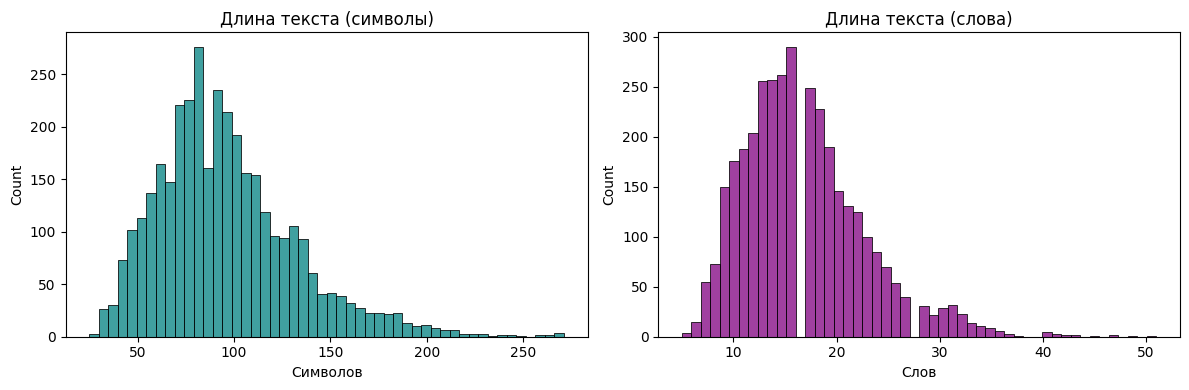

In [7]:
# визуализируем распределение длины текстов в символах и словах

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(nlp_train["len_chars"], bins=50, ax=axes[0], color="teal")
axes[0].set_title("Длина текста (символы)")
axes[0].set_xlabel("Символов")

sns.histplot(nlp_train["len_words"], bins=50, ax=axes[1], color="purple")
axes[1].set_title("Длина текста (слова)")
axes[1].set_xlabel("Слов")

plt.tight_layout()
plt.show()

In [8]:
# посмотрим на квантили длины текстов в словах, чтобы понять, какие максимальные длины нам нужно поддерживать при токенизации

nlp_train["len_words"].quantile([0.5, 0.8, 0.9, 0.95, 0.99])

0.50    16.00
0.80    21.00
0.90    25.00
0.95    28.00
0.99    34.55
Name: len_words, dtype: float64

Для всех текстов применялась следующая очистка:

- приведение к нижнему регистру
- удаление спецсимволов и цифр, сохранение русских и латинских букв
- нормализация пробелов

Для предварительного анализа текстов использовалась простая токенизация по пробелам. Однако для обучения трансформерных моделей будем применять встроенные токенизаторы соответствующих моделей (`ruBERT-tiny` и `ruBERT-base`), поскольку они выполняют subword-токенизацию и формируют вход в формате, необходимом для BERT-архитектуры.

## 2.2 Анализ текста Самые частые слова

In [9]:
# проведем анализ самых частых слов в текстах, чтобы понять, какие слова могут быть полезными для модели, а какие стоит убрать как стоп-слова

from sklearn.feature_extraction.text import CountVectorizer

ru_stopwords = [
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "ее", "мне", "есть", "они", "тут", "где", "когда", "из", "или",
    "при", "это", "от", "до", "мы", "вас", "для", "меня", "уже", "ли",
    "меня", "могу", "может", "можно", "быть", "нужно", "какие", "какой", "сказал", 
    "сказала", "делать", "после", "при", "уже"
]

cv1 = CountVectorizer(stop_words=ru_stopwords, max_features=30_000)
X1 = cv1.fit_transform(nlp_train["text_clean"])
words1 = cv1.get_feature_names_out()
freq1 = X1.sum(axis=0).A1

top_unigrams = (
    pd.DataFrame({"token": words1, "count": freq1})
    .sort_values("count", ascending=False)
    .head(20)
)
top_unigrams

,token,count
164,болит,920
316,врач,541
2011,постоянно,422
1662,особенно,349
2048,появились,261
1417,неделю,257
3056,часто,211
1044,крови,210
1339,назначил,210
444,голова,199


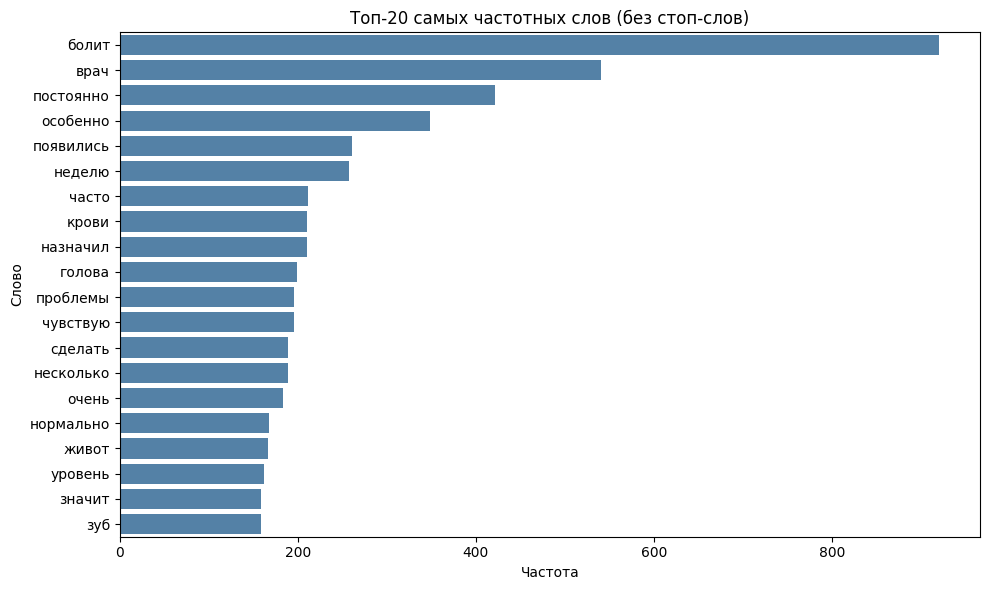

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_unigrams, x="count", y="token", color="steelblue")
plt.title("Топ-20 самых частотных слов (без стоп-слов)")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.tight_layout()
plt.show()

Самые частые слова в текстах: болит, врач, голова, живот, крови, сдать. Наряду с ними встречаются общие разговорные слова, что типично для свободных обращений пациентов. TF-IDF снижает вес частых, но малоинформативных слов.

In [11]:
# сделаем то же самое для биграмм, чтобы понять, какие словосочетания могут быть полезными для модели

cv2 = CountVectorizer(stop_words=ru_stopwords, ngram_range=(2, 2), max_features=50_000)
X2 = cv2.fit_transform(nlp_train["text_clean"])
bigrams = cv2.get_feature_names_out()
freq2 = X2.sum(axis=0).A1

top_bigrams = (
    pd.DataFrame({"bigram": bigrams, "count": freq2})
    .sort_values("count", ascending=False)
    .head(20)
)
top_bigrams

,bigram,count
1042,врач назначил,184
468,болит голова,174
473,болит живот,159
478,болит зуб,151
5205,несколько дней,116
4410,мой ребенок,99
10382,чувствую себя,87
6373,повышенный уровень,84
9863,учащенное сердцебиение,83
7052,появилась сыпь,79


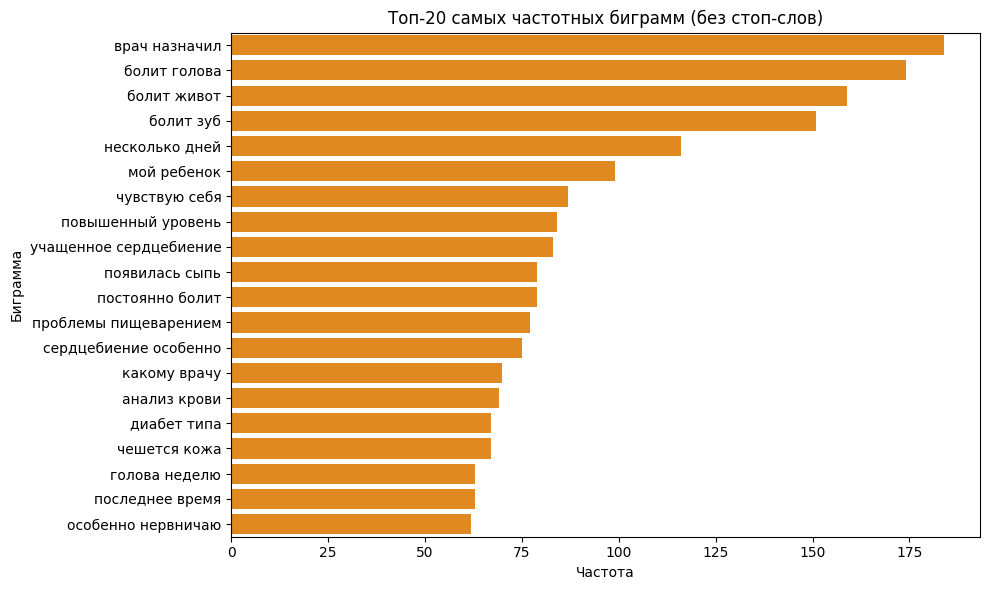

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_bigrams, x="count", y="bigram", color="darkorange")
plt.title("Топ-20 самых частотных биграмм (без стоп-слов)")
plt.xlabel("Частота")
plt.ylabel("Биграмма")
plt.tight_layout()
plt.show()

Анализ биграмм выявил устойчивые симптоматические сочетания: болит голова, болит живот, болит зуб, учащенное сердцебиение, анализ крови, диабет типа. Это подтвердило целесообразность использования n-грамм в классических моделях.

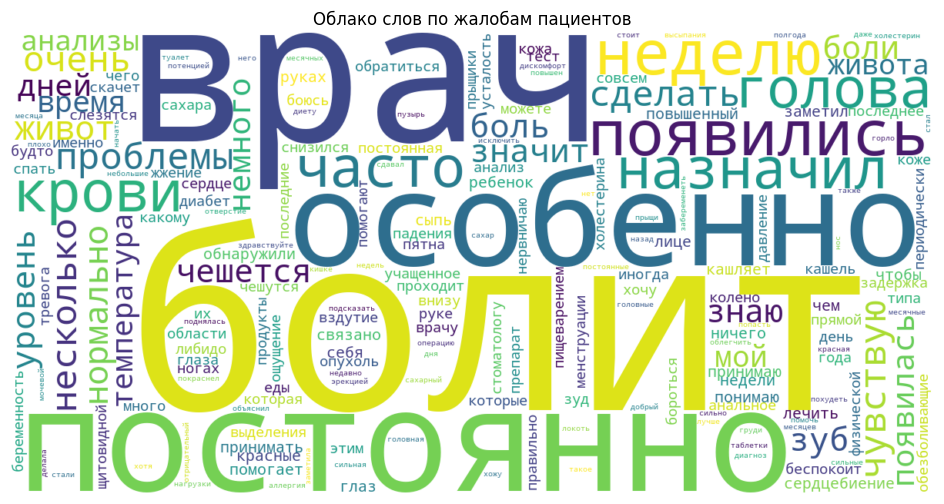

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_blob = " ".join(nlp_train["text_clean"].tolist())

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set(ru_stopwords),
    collocations=False
).generate(text_blob)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов по жалобам пациентов")
plt.show()

Облако слов подтверждает результаты частотного анализа: в текстах преобладают слова, связанные с симптомами, самочувствием и результатами обследований. Это указывает на то, что входные тексты действительно содержат признаки, полезные для классификации по специалистам.

## Основной вывод 
Данные содержат достаточно информативные текстовые признаки для классификации.

## 2.3 Анализ и нормализация целевой переменной `to_doctor`

In [14]:
# подготовим целевую переменную для модели создавая новый столбец "target", который будет строковым представлением столбца "to_doctor". 
# Это нужно для удобства при дальнейшей обработке и для работы моделей.

nlp_train["target"] = nlp_train["to_doctor"].astype(str)
nlp_test["target"] = nlp_test["to_doctor"].astype(str)

train_unique_df = pd.DataFrame({
    "train_target": sorted(nlp_train["target"].unique())
})

test_unique_df = pd.DataFrame({
    "test_target": sorted(nlp_test["target"].unique())
})

display(train_unique_df.tail(50))
display(test_unique_df)

,train_target
54,онколог-гинеколог
55,онколог-нейрохирург
56,онкология
57,ортопед
58,отоларинголог
59,оториноларинголог
60,офтальмолог
61,офтальмология
62,педиатр
63,педиатрия


,test_target
0,аллерголог
1,андролог
2,врач-уролог
3,гастроэнтеролог
4,генетик
5,гепатолог
6,гинеколог
7,гинеколог-онколог
8,гинеколог-репродуктолог
9,гинеколог-эндокринолог


По оценке целевой переменной видно несогласованные варианты названий одной и той же специальности, например «невролог» и «нейролог», «лор» и «отоларинголог», «семейный врач» и «терапевт». Многие специальности двойные через слэш или запятую. Очевидно что необходимо привести все специальности к единому названию.

In [15]:
# Создадим таблицу KEYWORDS_MAP, приводящую все варианты написания к единому виду

KEYWORDS_MAP = {
    "гинек": "гинеколог",
    "аллер": "аллерголог",
    "дерм": "дерматолог",
    "кард": "кардиолог",
    "невр": "невролог",
    "офта": "офтальмолог",
    "стома": "стоматолог",
    "эндок": "эндокринолог",
    "псих": "психиатр",
    "уро": "уролог",
    "андр": "андролог",
    "хир": "хирург",
    "мам": "маммолог",
    "репрод": "репродуктолог",
    "гастр": "гастроэнтеролог",
    "травм": "травматолог",
    "орто": "ортопед",
    "педи": "педиатр",
    "тер": "терапевт",
    "диет": "диетолог",
    "нутр": "диетолог",
    "гемат": "гематолог",
    "онкол": "онколог",
    "косм": "косметолог",
    "генет": "генетик",
    "ото": "лор",
    "лор": "лор",
    "семейн": "терапевт",
    "общей": "терапевт",
    "нейр": "невролог",
    "plast": "хирург",
    "астм": "эндокринолог",
    "нефр": "нефролог",
    "прокт": "проктолог"
}

In [16]:
# создадим функцию normalize_specialty_fast, которая будет быстро приводить все варианты написания к единому виду, 
# используя KEYWORDS_MAP.

def normalize_specialty_fast(label):
    label = str(label).strip().lower()
    label = re.sub(r"[^\w\s/-]", " ", label)
    label = re.sub(r"\s+", " ", label).strip()

    for key, canonical in KEYWORDS_MAP.items():
        if key in label:
            return canonical

    return label

In [17]:
# создадим новый нормализованный столбец "target_norm", который будет содержать нормализованные значения специальностей 
# для обучения модели.

nlp_train["target_norm"] = nlp_train["target"].apply(normalize_specialty_fast)
nlp_test["target_norm"] = nlp_test["target"].apply(normalize_specialty_fast)

In [18]:
# Проверим совпадают ли классы в train и test после нормализации.

nlp_train_classes = set(nlp_train["target_norm"].unique())
nlp_test_classes = set(nlp_test["target_norm"].unique())
missing_1 = sorted(nlp_test_classes - nlp_train_classes)

missing_2 = sorted(nlp_train_classes - nlp_test_classes)

print("Классов в test, которых нет в train:", len(missing_1))
missing_1[:20]

Классов в test, которых нет в train: 2


['инфекционист', 'флеболог']

после проведения нормализации осталось 2 специальности в test которых нет в train. Приведем их к общей близкой им специольности.

In [19]:
# дополним функцию normalize_specialty_fast, чтобы она также обрабатывала некоторые специфические случаи, 
# которые не покрываются KEYWORDS_MAP, например "инфекционист" - "терапевт", "флеболог" - "хирург". 

def normalize_specialty_fast(label):
    
    for key, canonical in KEYWORDS_MAP.items():
        if key in label:
            return canonical
    if label in {"инфекционист"}:
        return "терапевт"
    if label in {"флеболог"}:
        return "хирург"

    return label

In [20]:
nlp_train["target_norm"] = nlp_train["target"].apply(normalize_specialty_fast)
nlp_test["target_norm"] = nlp_test["target"].apply(normalize_specialty_fast)

In [21]:
nlp_train_classes = set(nlp_train["target_norm"].unique())
nlp_test_classes = set(nlp_test["target_norm"].unique())
missing_1 = sorted(nlp_test_classes - nlp_train_classes)

missing_2 = sorted(nlp_train_classes - nlp_test_classes)

print("Классов в test, которых нет в train:", len(missing_1))
missing_1[:20]

Классов в test, которых нет в train: 0


[]

После обработки отсутствующих специальностей мы видим что различий нет

In [22]:
# посмотрим что получилось после нормализации классов в train и test, чтобы убедиться, 
# что теперь они совпадают и модель сможет обучаться на всех классах.

train_unique_df = pd.DataFrame({
    "train_target": sorted(nlp_train["target_norm"].unique())
})

test_unique_df = pd.DataFrame({
    "test_target": sorted(nlp_test["target_norm"].unique())
})

display(train_unique_df)
display(test_unique_df)

,train_target
0,аллерголог
1,андролог
2,врач
3,гастроэнтеролог
4,гематолог
5,генетик
6,гепатолог
7,гинеколог
8,дерматолог
9,диетолог


,test_target
0,аллерголог
1,андролог
2,гастроэнтеролог
3,генетик
4,гепатолог
5,гинеколог
6,дерматолог
7,диетолог
8,кардиолог
9,косметолог


Стало намного лучше, все классы приведены к единому написанию и нет различий с тестовой выборкой.
Есть непонятный класс врач посмотрим на него поближе и решим что делать

In [23]:
display(
    nlp_train.loc[
        nlp_train["target_norm"].astype(str).str.contains("врач", case=False, na=False),
        ["user_question", "target_norm"]
    ]
)

,user_question,target_norm
2199,У меня постоянная усталость и снижение концент...,врач


так как врач это одна строка удалим ее без проблем 

In [24]:
# создам копию датафрейма для экспериментов для обработки и удалим строку врач по индексу.

nlp_train_2 = nlp_train.copy()

nlp_train_2 = nlp_train_2.drop(index=2199)

display(
    nlp_train_2.loc[
        nlp_train_2["target_norm"].astype(str).str.contains("врач", case=False, na=False),
        ["user_question", "target_norm"]
    ]
)

,user_question,target_norm


Проведена Нормализация целевой переменной

Исходная разметка содержала несогласованные варианты названий одной и той же специальности, например «невролог» и «нейролог», «лор» и «отоларинголог», «семейный врач» и «терапевт». Для унификации была составлена таблица KEYWORDS_MAP, приводящая все варианты написания к единому каноническому названию специальности.

Дополнительно:
- класс «инфекционист» объединён с «терапевт»
- класс «флеболог» объединён с «хирург»
- единственная запись с классом «врач» (строка 2199) была удалена как неинформативная

## 2.4 Анализ классов

In [25]:
class_counts = nlp_train_2["target_norm"].value_counts()

print("Всего объектов:", len(nlp_train_2))
print("Всего классов:", nlp_train_2["target_norm"].nunique())
print("Мин. примеров в классе:", class_counts.min())
print("Макс. примеров в классе:", class_counts.max())
print("Медиана примеров в классе:", int(class_counts.median()))
print("Классы с 1 примером:", int((class_counts == 1).sum()))
print("Классы с <=3 примерами:", int((class_counts <= 3).sum()))

Всего объектов: 3545
Всего классов: 31
Мин. примеров в классе: 1
Макс. примеров в классе: 277
Медиана примеров в классе: 112
Классы с 1 примером: 3
Классы с <=3 примерами: 3


Вывод по распределению классов

Перед обучением моделей была проанализирована структура целевой переменной target_norm. После нормализации названий врачебных специальностей в обучающей выборке осталось 3545 объектов и 31 класс. При этом распределение классов оказалось неравномерным.

Минимальное число примеров в классе составляет 1, максимальное — 277, медиана — 112. Это означает, что половина классов содержит не более 112 объектов, тогда как отдельные направления представлены значительно большим количеством примеров. Таким образом, в данных наблюдается дисбаланс классов: наряду с хорошо представленными специальностями есть и очень редкие категории.

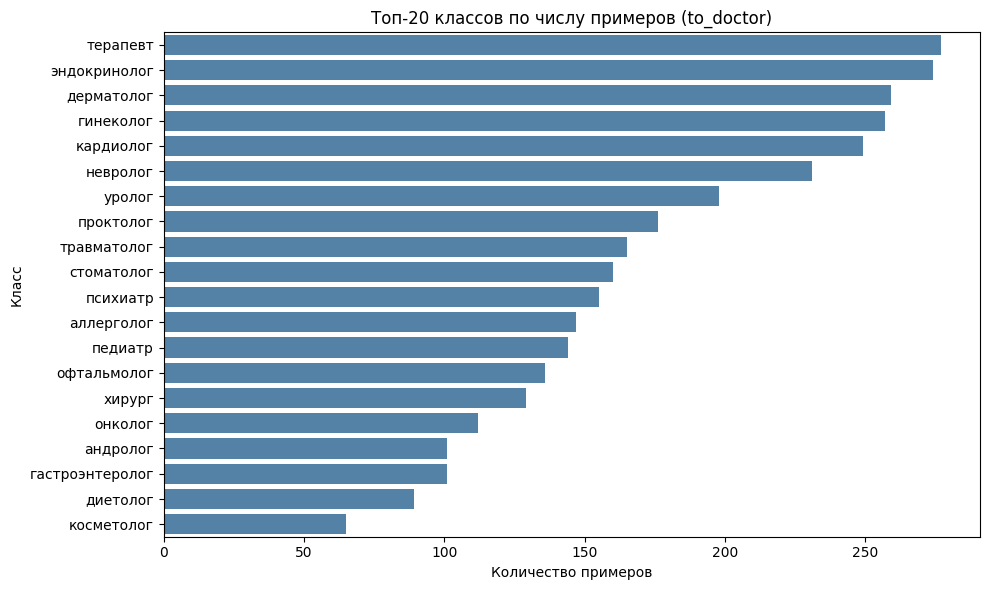

In [26]:
top_n = 20
top_counts = class_counts.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_counts.values, y=top_counts.index, color="steelblue")
plt.title(f"Топ-{top_n} классов по числу примеров (to_doctor)")
plt.xlabel("Количество примеров")
plt.ylabel("Класс")
plt.tight_layout()
plt.show()

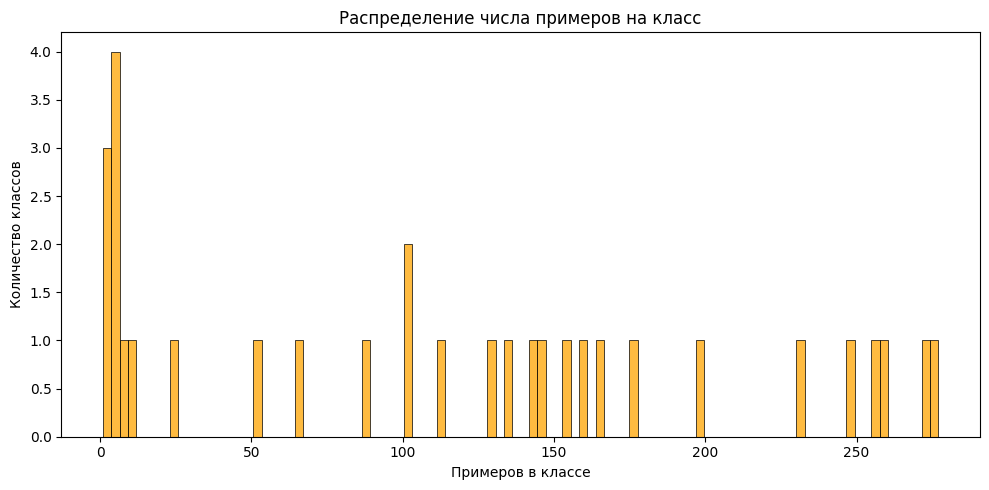

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(class_counts.values, bins=100, color="orange")
plt.title("Распределение числа примеров на класс")
plt.xlabel("Примеров в классе")
plt.ylabel("Количество классов")
plt.tight_layout()
plt.show()

Гистограмма показывает, что большинство классов распределено неравномерно, а само распределение имеет выраженную асимметрию. В данных присутствует небольшое число очень редких классов и одновременно группа достаточно крупных классов с числом примеров от примерно 100 до 280. То есть распределение нельзя считать сбалансированным: модель будет обучаться в условиях, где одни специальности представлены существенно лучше других.

Особенно важно, что в выборке есть 3 класса, представленные всего одним примером. Такие классы затрудняют стратифицированное разбиение на train/validation и не позволяют корректно оценивать качество модели на валидации.

In [28]:
# Создадим train_model для разделения ее в дальнейшем на train и validation для сравнения моделей и выбора лучшей 
# Оставляем только классы, где >= 2 примеров

class_counts = nlp_train_2["target_norm"].value_counts()
valid_classes = class_counts[class_counts >= 2].index

train_model = nlp_train_2[nlp_train_2["target_norm"].isin(valid_classes)].copy() # фильтруем редкие классы

print("Изначально объектов:", len(nlp_train_2))
print("После фильтрации редких классов:", len(train_model))
print("Изначально классов:", nlp_train_2["target_norm"].nunique())
print("После фильтрации классов:", train_model["target_norm"].nunique())

Изначально объектов: 3545
После фильтрации редких классов: 3542
Изначально классов: 31
После фильтрации классов: 28


Для корректного сравнения моделей обучающая выборка была временно очищена от классов, содержащих менее двух примеров. После этого:

число объектов уменьшилось с 3545 до 3542;
число классов сократилось с 31 до 28.
Удаление затронуло всего 3 объекта, поэтому практически не повлияло на общий объём данных, но позволило избежать проблем при стратифицированном разбиении на обучающую и валидационную выборки.

Важно, что это решение было принято только для этапа модельного сравнения и валидации. На этапе финального обучения на полном тренировочном наборе редкие классы могут быть возвращены обратно.

## Основной вывод
Наличие дисбаланса означает, что при оценке качества моделей особенно важно ориентироваться не только на accuracy, но и на macro F1-score, поскольку эта метрика лучше отражает качество классификации по всем классам, включая менее представленные.

# 3. Моделирование

## 3.1 Построим baseline модель TF-IDF + LinearSVC
В качестве первой модели использован pipeline из TF-IDF векторизатора (юниграммы и биграммы, min_df=2, max_features=200 000) и линейного SVM (LinearSVC)

In [29]:
# разделим train_model на train и validation, чтобы потом сравнивать модели и выбирать лучшую

from sklearn.model_selection import train_test_split

X = train_model["text_clean"]
y = train_model["target_norm"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))

Train size: 2833
Val size: 709


In [30]:
# обучим простую модель на основе SVM с TF-IDF признаками, чтобы получить базовую линию для сравнения с 
# более сложными моделями на трансформерах.

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline(           # создаем пайплайн, который сначала преобразует текст в TF-IDF признаки, а затем обучает линейный SVM
    steps=[
        (
            "tfidf",                  # настройки TF-IDF векторайзера:  
            TfidfVectorizer(
                ngram_range=(1, 2),   # используем униграммы и биграммы
                min_df=2,             # игнорируем слова, которые встречаются менее 2 раз
                max_features=200_000  # и ограничиваем количество признаков 200_000
            )
        ),
        ("clf", LinearSVC())          # используем линейный SVM для классификации
    ]
)

svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [31]:
# оценим качество модели на train и validation, используя метрики accuracy и macro F1-score, 
# чтобы понять, как модель справляется с задачей и есть ли признаки переобучения. 

from sklearn.metrics import accuracy_score, f1_score

y_train_pred = svm_pipeline.predict(X_train)    # предсказания на train
y_val_pred = svm_pipeline.predict(X_val)        # предсказания на validation

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

train_f1 = f1_score(y_train, y_train_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Train Macro F1: {train_f1:.4f}")
print(f"Validation Macro F1: {val_f1:.4f}")

Train Accuracy: 0.9672
Validation Accuracy: 0.8011
Train Macro F1: 0.9643
Validation Macro F1: 0.6174


## Вывод

**TF-IDF + LinearSVC**

| Метрика | Train | Val |
|---|---|---|
| Accuracy | 0.9672 | 0.8011 |
| Macro F1 | 0.9643 | 0.6174 |

Модель показала сильный результат и установила высокую планку для нейросетевых подходов. Существенный разрыв между train и val метриками указывает на переобучение, характерное для LinearSVC на небольших многоклассовых задачах с редкими классами.



## 3.2 Построим простую нейросеть на PyTorch (Embedding + Average Pooling)

Архитектура: слой Embedding → усреднение с маскировкой PAD-токенов → Dropout(0.3) → линейный классификатор. Словарь: 20 000 наиболее частых слов. Обучение с Adam, lr=1e-3, CrossEntropyLoss, early stopping по val loss с patience=3.

In [32]:
# разделим train_model на train и validation, чтобы потом сравнивать модели и выбирать лучшую, 
# используя закодированные метки классов для обучения моделей, которые требуют числовые метки.

from sklearn.model_selection import train_test_split

X = train_model["text_clean"].fillna("").astype(str).tolist() # преобразуем текст в список строк
le = LabelEncoder()                                 # создаем экземпляр LabelEncoder для кодирования строковых меток классов в числовые
y_encoded = le.fit_transform(train_model["target_norm"].astype(str)) # кодируем строковые метки классов в числовые
y = y_encoded 

X_train, X_val, y_train, y_val = train_test_split(  # разделяем данные на train и validation 
    X,
    y,
    test_size=0.2,   # выделяем 20% данных для validation
    random_state=42, # фиксируем случайное состояние для воспроизводимости
    stratify=y       # используя стратификацию по классам для сохранения пропорций классов в обоих наборах
)

print(len(X_train), len(X_val))

2833 709


In [33]:
# в ручную сделаем словарь для простой нейросетевой модели на словах 
# для преобразования слов в числовые индексы, который будет использоваться для обучения модели
from collections import Counter

def tokenize_text(text: str) -> list[str]:
    return text.split()

counter = Counter()

for text in X_train:
    counter.update(tokenize_text(text))

max_vocab_size = 20000

most_common_words = counter.most_common(max_vocab_size - 2)

word2idx = {"<PAD>": 0, "<UNK>": 1}
for idx, (word, _) in enumerate(most_common_words, start=2):
    word2idx[word] = idx

vocab_size = len(word2idx)
print("Размер словаря:", vocab_size)

Размер словаря: 2900


In [34]:
def encode_text(text: str, word2idx: dict, max_len: int = 40) -> list[int]:
    tokens = tokenize_text(text)
    ids = [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]
    ids = ids[:max_len]
    ids += [word2idx["<PAD>"]] * (max_len - len(ids))
    return ids

max_len = 40

X_train_ids = [encode_text(text, word2idx, max_len=max_len) for text in X_train]
X_val_ids = [encode_text(text, word2idx, max_len=max_len) for text in X_val]

На этом этапе тексты были преобразованы в последовательности индексов слов с помощью словаря `word2idx`. Неизвестные слова заменялись на токен `<UNK>`, а короткие последовательности дополнялись `<PAD>` до фиксированной длины `max_len = 40`. Это позволило представить все тексты в едином числовом формате, пригодном для подачи в нейросетевую модель.

In [35]:
import torch

X_train_tensor = torch.tensor(X_train_ids, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_ids, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)

torch.Size([2833, 40]) torch.Size([2833])
torch.Size([709, 40]) torch.Size([709])


На этом этапе последовательности индексов слов и целевые метки были преобразованы в тензоры PyTorch. Для текстов использовался тип `torch.long`, поскольку индексы слов далее подаются на вход слою `Embedding`, а метки классов также были приведены к `torch.long` для корректной работы функции потерь `CrossEntropyLoss`.

In [36]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

После преобразования текстов и меток в тензоры данные были упакованы в объекты `TensorDataset`, а затем для них были созданы `DataLoader`. Это позволило подавать данные в модель батчами по 32 объекта. Для обучающей выборки использовалось перемешивание (`shuffle=True`), чтобы повысить устойчивость обучения, тогда как для валидационной выборки порядок объектов сохранялся.

In [37]:
import torch.nn as nn

class TextClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, num_classes: int, pad_idx: int = 0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)  # [batch, seq_len, embed_dim]
        
        mask = (x != 0).unsqueeze(-1)  # не учитываем PAD
        embedded = embedded * mask
        
        lengths = mask.sum(dim=1).clamp(min=1)  # [batch, 1]
        pooled = embedded.sum(dim=1) / lengths  # average pooling
        
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

В качестве простой нейросетевой baseline-модели использовалась архитектура `Embedding + Average Pooling + Linear`. Каждый текст представлялся как последовательность индексов слов, после чего токены преобразовывались в обучаемые эмбеддинги. Затем эмбеддинги усреднялись по всем непустым токенам текста (с исключением `<PAD>`), и полученное векторное представление подавалось на линейный классификатор. Для снижения переобучения перед выходным слоем применялся `Dropout(0.3)`.

In [38]:
num_classes = len(le.classes_)
print("num_classes =", num_classes)

num_classes = 28


In [39]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

embed_dim = 128

model_torch = TextClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

Device: mps


На этом этапе было выбрано вычислительное устройство для обучения модели: `mps`, если доступно аппаратное ускорение на Apple Silicon, иначе `cpu`. Далее была создана простая текстовая классификационная модель `TextClassifier` с размерностью эмбеддингов `128`. Модель была сразу перенесена на выбранное устройство, чтобы обеспечить корректное и более быстрое обучение.

In [40]:
from sklearn.metrics import accuracy_score, f1_score

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_torch.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, acc, f1


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, acc, f1

Для обучения простой нейросетевой модели использовалась функция потерь `CrossEntropyLoss`, подходящая для многоклассовой классификации, и оптимизатор `Adam` с шагом обучения `1e-3`. Были реализованы две функции: `train_epoch()` для одной эпохи обучения модели на обучающей выборке и `eval_epoch()` для оценки качества на валидационной выборке. В обеих функциях после прохода по всем батчам рассчитывались `loss`, `accuracy` и `macro F1`.

In [41]:
num_epochs = 15
history_torch = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

best_val_loss = float("inf")
patience = 3
patience_counter = 0
best_state = None

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_epoch(
        model_torch, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc, val_f1 = eval_epoch(
        model_torch, val_loader, criterion, device
    )

    history_torch["train_loss"].append(train_loss)
    history_torch["train_acc"].append(train_acc)
    history_torch["train_f1"].append(train_f1)
    history_torch["val_loss"].append(val_loss)
    history_torch["val_acc"].append(val_acc)
    history_torch["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
        f"train_f1={train_f1:.4f} val_f1={val_f1:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model_torch.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model_torch.load_state_dict(best_state)

Epoch 1/15 | train_loss=3.0724 val_loss=2.8501 | train_acc=0.2121 val_acc=0.3597 | train_f1=0.1297 val_f1=0.2057
Epoch 2/15 | train_loss=2.6419 val_loss=2.5081 | train_acc=0.4162 val_acc=0.4570 | train_f1=0.2608 val_f1=0.2838
Epoch 3/15 | train_loss=2.2958 val_loss=2.2186 | train_acc=0.5051 val_acc=0.5219 | train_f1=0.3289 val_f1=0.3398
Epoch 4/15 | train_loss=1.9995 val_loss=1.9701 | train_acc=0.5739 val_acc=0.5698 | train_f1=0.3842 val_f1=0.3808
Epoch 5/15 | train_loss=1.7479 val_loss=1.7661 | train_acc=0.6198 val_acc=0.5994 | train_f1=0.4284 val_f1=0.4098
Epoch 6/15 | train_loss=1.5359 val_loss=1.6042 | train_acc=0.6615 val_acc=0.6319 | train_f1=0.4805 val_f1=0.4477
Epoch 7/15 | train_loss=1.3716 val_loss=1.4706 | train_acc=0.6986 val_acc=0.6488 | train_f1=0.5130 val_f1=0.4815
Epoch 8/15 | train_loss=1.2295 val_loss=1.3630 | train_acc=0.7233 val_acc=0.6671 | train_f1=0.5478 val_f1=0.4974
Epoch 9/15 | train_loss=1.1222 val_loss=1.2759 | train_acc=0.7441 val_acc=0.6841 | train_f1=0.56

## Вывод:

| Метрика | Train | Val |
|---|---|---|
| Accuracy | 0.8168 | 0.7405 |
| Macro F1 | 0.6309 | 0.5604 |

Простая PyTorch-модель показала стабильное обучение: `val_loss` снижался на протяжении всех 15 эпох, а `val_macro_f1` вырос с `0.2057` до `0.5604`. Это подтверждает, что модель смогла выучить полезные закономерности в данных, однако по качеству она уступила как `TF-IDF + LinearSVC`, так и трансформерным моделям. Кроме того, реализация такого решения вручную в PyTorch оказалась довольно громоздкой и трудоёмкой, поскольку потребовала отдельно строить словарь, кодировать тексты, подготавливать тензоры и писать собственный цикл обучения.

## 3.3 Построим трансформер ruBERT-tiny (`cointegrated/rubert-tiny2`)

Компактная русскоязычная BERT-модель. Параметры обучения: `lr=5e-5`, `batch_size=8`, `num_epochs=7`, `weight_decay=0.01`, выбор лучшей эпохи по `macro_f1`.

In [42]:
# подготовим данные для обучения модели на трансформере, используя закодированные метки классов и очищенный текст.

X = train_model["text_clean"].tolist()
y = train_model["target_norm"].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
print("Количество классов:", num_classes)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))

Количество классов: 28
Train size: 2833
Val size: 709


In [43]:
# токенизатор для модели на трансформере, который будет преобразовывать текст в числовые токены
from transformers import AutoTokenizer

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [44]:
# создадим объекты Dataset для train и validation, которые будут использоваться для обучения модели на трансформере
from datasets import Dataset

train_ds = Dataset.from_dict({
    "text": X_train,
    "label": y_train
})

val_ds = Dataset.from_dict({
    "text": X_val,
    "label": y_val
})

In [45]:
# создадим функцию tokenize_batch, которая будет использовать токенизатор для преобразования текста в числовые токены

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds = val_ds.map(tokenize_batch, batched=True)

train_ds = train_ds.remove_columns(["text"])
val_ds = val_ds.remove_columns(["text"])

train_ds.set_format("torch")
val_ds.set_format("torch")

Map:   0%|          | 0/2833 [00:00<?, ? examples/s]

Map:   0%|          | 0/709 [00:00<?, ? examples/s]

In [46]:
# создадим модель на основе трансформера, которая будет использовать предобученные веса и будет 
# адаптирована для нашей задачи классификации с num_classes классами

from transformers import AutoTokenizer, BertForSequenceClassification

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model_bert = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [47]:
# создадим функцию compute_metrics, которая будет использоваться для оценки качества модели на трансформере во время обучения, 
# используя метрики accuracy и macro F1-score для оценки производительности модели на validation наборе.

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

if not hasattr(np, "_original_array"):
    np._original_array = np.array

def _np_array_compat(obj, *args, **kwargs):
    if kwargs.get("copy") is False:
        kwargs.pop("copy", None)
        return np.asarray(obj, *args, **kwargs)
    return np._original_array(obj, *args, **kwargs)

np.array = _np_array_compat

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [48]:
# настроим параметры обучения для модели на трансформере, чтобы оптимизировать процесс обучения 
# и добиться лучших результатов на validation наборе

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./rubert_tiny2_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=7,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=42,
    data_seed=42
)

In [49]:
# создадим объект Trainer для обучения модели на трансформере, 
# который будет использовать все ранее созданные компоненты: модель, данные, метрики и параметры обучения

from transformers import Trainer

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/var/folders/9v/hrsv8hyn0gnf8yc8j_fw54tm0000gp/T/ipykernel_30499/1320384004.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [50]:
# запустим процесс обучения модели на трансформере, который будет оптимизировать модель на основе 
# validation метрик и сохранять лучшую модель по macro F1-score

trainer.train()

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.811200,2.250130,0.643159,0.412364
2,1.898000,1.549607,0.726375,0.490657
3,1.358700,1.196169,0.767278,0.558215
4,1.067700,1.005214,0.775740,0.567488
5,0.908700,0.904464,0.787024,0.577675
6,0.817700,0.857388,0.789845,0.582198
7,0.765300,0.842675,0.798307,0.597926


/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not suppo

TrainOutput(global_step=2485, training_loss=1.3753384073975101, metrics={'train_runtime': 169.1573, 'train_samples_per_second': 117.234, 'train_steps_per_second': 14.69, 'total_flos': 18341709033984.0, 'train_loss': 1.3753384073975101, 'epoch': 7.0})

In [51]:
# оценим качество обученной модели на трансформере на validation наборе, используя метрики accuracy и macro F1-score

metrics_bert = trainer.evaluate()
metrics_bert

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.8426746129989624,
 'eval_accuracy': 0.7983074753173484,
 'eval_macro_f1': 0.5979262981044113,
 'eval_runtime': 0.4081,
 'eval_samples_per_second': 1737.422,
 'eval_steps_per_second': 218.097,
 'epoch': 7.0}

## Вывод

| Метрика | Val |
|---|---|
| Accuracy | 0.7983 |
| Macro F1 | 0.5979 |

Несмотря на компактный размер, модель показала результат, сопоставимый с baseline. Предобученные веса на русском корпусе позволяют эффективно работать даже на небольших данных.

## 3.4 Трансформер ruBERT-base (`DeepPavlov/rubert-base-cased`)

Полноразмерная русскоязычная BERT-модель. Параметры: `lr=3e-5`, `batch_size=5`, `num_epochs=7`, `weight_decay=0.01`, выбор лучшей эпохи по `macro_f1`.

In [52]:
# подготовим модель на основе другого предобученного трансформера, 
# чтобы сравнить результаты и выбрать лучшую модель для финального тестирования

from transformers import BertTokenizer, BertForSequenceClassification

model_name = "DeepPavlov/rubert-base-cased"

tokenizer_base = BertTokenizer.from_pretrained(model_name)

model_rubert_base = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [53]:
# подготовим данные для обучения модели на другом трансформере, используя закодированные метки классов и очищенный текст,
# аналогично тому, как мы подготовили данные для первой модели на трансформере, 
# чтобы обеспечить справедливое сравнение между моделями и выбрать лучшую для финального тестирования

X = train_model["text_clean"].tolist()
y = train_model["target_norm"].tolist()

label_encoder_bert = LabelEncoder()
y_encoded_bert = label_encoder_bert.fit_transform(y)

num_classes = len(label_encoder_bert.classes_)
print("Количество классов:", num_classes)

X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X,
    y_encoded_bert,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_bert
)

print("Train size:", len(X_train_bert))
print("Val size:", len(X_val_bert))

Количество классов: 28
Train size: 2833
Val size: 709


In [54]:
# создадим объекты Dataset для train и validation для второй модели на трансформере

from datasets import Dataset

train_ds_base = Dataset.from_dict({
    "text": X_train_bert,
    "label": y_train_bert
})

val_ds_base = Dataset.from_dict({
    "text": X_val_bert,
    "label": y_val_bert
})

In [55]:
# токенизация текста для второй модели 

def tokenize_batch_base(batch):
    return tokenizer_base(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_ds_base = train_ds_base.map(tokenize_batch_base, batched=True)
val_ds_base = val_ds_base.map(tokenize_batch_base, batched=True)

train_ds_base = train_ds_base.remove_columns(["text"])
val_ds_base = val_ds_base.remove_columns(["text"])

train_ds_base.set_format("torch")
val_ds_base.set_format("torch")

Map:   0%|          | 0/2833 [00:00<?, ? examples/s]

Map:   0%|          | 0/709 [00:00<?, ? examples/s]

In [56]:
# метрики

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [57]:
# настроим параметры обучения

from transformers import TrainingArguments

training_args_base = TrainingArguments(
    output_dir="./rubert_base_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=5,
    per_device_eval_batch_size=5,
    num_train_epochs=7,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=42,
    data_seed=42
)

In [58]:
from transformers import Trainer

trainer_base = Trainer(
    model=model_rubert_base,
    args=training_args_base,
    train_dataset=train_ds_base,
    eval_dataset=val_ds_base,
    tokenizer=tokenizer_base,
    compute_metrics=compute_metrics,
)

/var/folders/9v/hrsv8hyn0gnf8yc8j_fw54tm0000gp/T/ipykernel_30499/2503489231.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_base = Trainer(


In [59]:
import numpy as np

if not hasattr(np, "_original_array"):
    np._original_array = np.array

def _np_array_compat(obj, *args, **kwargs):
    if kwargs.get("copy") is False:
        kwargs.pop("copy", None)
        return np.asarray(obj, *args, **kwargs)
    return np._original_array(obj, *args, **kwargs)

np.array = _np_array_compat

In [60]:
train_result_base = trainer_base.train()
metrics_base = trainer_base.evaluate()
metrics_base

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.684500,0.793167,0.803949,0.587780
2,0.682800,0.718200,0.792666,0.581232
3,0.511600,0.788553,0.808181,0.624667
4,0.422500,0.811624,0.812412,0.623701
5,0.357500,0.832360,0.805360,0.616236
6,0.276600,0.915134,0.802539,0.614332
7,0.231500,0.943489,0.799718,0.612443


/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not suppo

{'eval_loss': 0.7885532379150391,
 'eval_accuracy': 0.8081805359661495,
 'eval_macro_f1': 0.6246666909919808,
 'eval_runtime': 2.1799,
 'eval_samples_per_second': 325.242,
 'eval_steps_per_second': 65.14,
 'epoch': 7.0}

## Вывод

| Метрика | Val |
|---|---|
| Accuracy | 0.8194 |
| Macro F1 | 0.6254 |


Лучший результат среди всех моделей в базовой постановке. Полноразмерный BERT лучше справляется с разграничением близких медицинских специальностей благодаря более богатому контекстному представлению. 

In [61]:
final_results = pd.DataFrame([
    {
        "model": "DeepPavlov/rubert-base-cased",
        "train_accuracy": None,
        "val_accuracy": 0.8194,
        "train_macro_f1": None,
        "val_macro_f1": 0.6254
    },
    {
        "model": "TF-IDF + LinearSVC",
        "train_accuracy": 0.9672,
        "val_accuracy": 0.8011,
        "train_macro_f1": 0.9643,
        "val_macro_f1": 0.6174
    },
    {
        "model": "ruBERT-tiny",
        "train_accuracy": None,
        "val_accuracy": 0.7983,
        "train_macro_f1": None,
        "val_macro_f1": 0.5979
    },
    {
        "model": "Simple PyTorch NN",
        "train_accuracy": 0.8168,
        "val_accuracy": 0.7405,
        "train_macro_f1": 0.6309,
        "val_macro_f1": 0.5604
    }
])

final_results.sort_values("val_macro_f1", ascending=False)

,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1
0,DeepPavlov/rubert-base-cased,NaN,0.8194,NaN,0.6254
1,TF-IDF + LinearSVC,0.9672,0.8011,0.9643,0.6174
2,ruBERT-tiny,NaN,0.7983,NaN,0.5979
3,Simple PyTorch NN,0.8168,0.7405,0.6309,0.5604


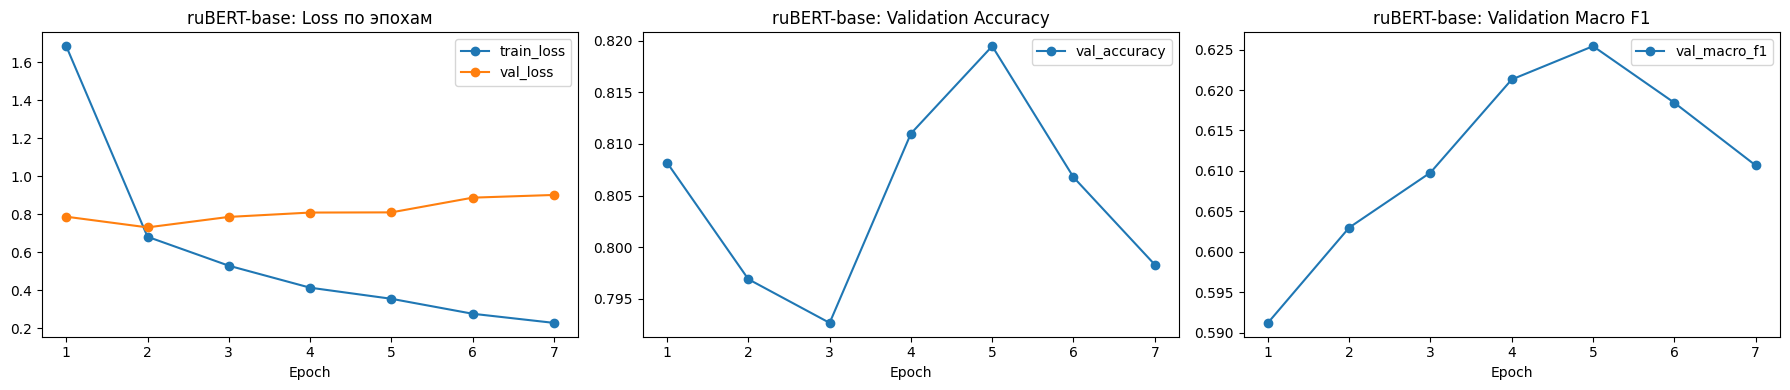

In [62]:
metrics_df = pd.DataFrame({
    "epoch": [1, 2, 3, 4, 5, 6, 7],
    "train_loss": [1.684500, 0.682200, 0.530100, 0.414500, 0.356100, 0.277400, 0.229400],
    "val_loss": [0.787797, 0.731575, 0.786632, 0.809539, 0.810504, 0.887895, 0.902147],
    "accuracy": [0.808181, 0.796897, 0.792666, 0.811001, 0.819464, 0.806770, 0.798307],
    "macro_f1": [0.591205, 0.602990, 0.609795, 0.621309, 0.625426, 0.618429, 0.610687]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(metrics_df["epoch"], metrics_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(metrics_df["epoch"], metrics_df["val_loss"], marker="o", label="val_loss")
axes[0].set_title("ruBERT-base: Loss по эпохам")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(metrics_df["epoch"], metrics_df["accuracy"], marker="o", label="val_accuracy")
axes[1].set_title("ruBERT-base: Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Macro F1
axes[2].plot(metrics_df["epoch"], metrics_df["macro_f1"], marker="o", label="val_macro_f1")
axes[2].set_title("ruBERT-base: Validation Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

## Основной вывод


Наилучший результат по основной метрике macro F1-score показала модель `DeepPavlov/rubert-base-cased`, достигнув значения `0.6254` на валидационной выборке. Второе место заняла модель `TF-IDF + LinearSVC` с результатом `0.6174`, показавшая очень сильный baseline. Компактная модель `ruBERT-tiny` также продемонстрировала высокое качество (`0.5079`), тогда как простая полносвязная нейросеть уступила более сложным подходам (`0.5604`).

# 4. Анализ ошибок

## 4.1 Разбор ошибок модели `DeepPavlov/rubert-base-cased`

In [63]:
# Анализ ошибок для BERT-base

# 1. Получаем предсказания модели
pred_output = trainer_base.predict(val_ds_base)
pred_logits = pred_output.predictions
pred_ids = np.argmax(pred_logits, axis=1)

# 2. Собираем таблицу
examples_df_bert = pd.DataFrame({
    "text": list(X_val_bert),
    "true_label": list(y_val_bert),
    "pred_label": list(pred_ids)
})

# 3. Проверка корректности размеров
assert len(X_val_bert) == len(y_val_bert) == len(pred_ids), "Длины текстов, истинных меток и предсказаний не совпадают"

# 4. Отмечаем правильные/неправильные ответы
examples_df_bert["correct"] = examples_df_bert["true_label"] == examples_df_bert["pred_label"]

# 5. Переводим индексы классов в названия
idx2label = {idx: label for idx, label in enumerate(label_encoder_bert.classes_)}
examples_df_bert["true_label_name"] = examples_df_bert["true_label"].map(idx2label)
examples_df_bert["pred_label_name"] = examples_df_bert["pred_label"].map(idx2label)

# 6. Случайные примеры из всей выборки
sample_examples_bert = examples_df_bert.sample(
    n=min(10, len(examples_df_bert)),
    random_state=42
)

print("Случайные примеры из валидации:")
display(sample_examples_bert[["text", "true_label_name", "pred_label_name", "correct"]])

# 7. Только ошибки модели
mistakes_df_bert = examples_df_bert[~examples_df_bert["correct"]].copy()

print(f"Всего ошибок модели: {len(mistakes_df_bert)} из {len(examples_df_bert)}")

sample_mistakes_bert = mistakes_df_bert.sample(
    n=min(20, len(mistakes_df_bert)),
    random_state=42
)

# 8. Красивый вывод ошибок
print("\nПримеры ошибочных предсказаний:\n")

for _, row in sample_mistakes_bert.iterrows():
    print("=" * 100)
    print("Текст:")
    print(row["text"])
    print()
    print("Истинный класс:", row["true_label_name"])
    print("Предсказанный класс:", row["pred_label_name"])
    print("Совпадение:", "Да" if row["correct"] else "Нет")

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Случайные примеры из валидации:


,text,true_label_name,pred_label_name,correct
294,у меня растяжение связок в локте врач сказал ч...,травматолог,травматолог,True
256,у меня на руке появилась сыпь красная и немног...,дерматолог,дерматолог,True
613,у меня болит голова слабость и высокая темпера...,терапевт,терапевт,True
357,у меня повышенный уровень холестерина врач ска...,эндокринолог,эндокринолог,True
248,мой ребенок постоянно чешется я уже купил ему ...,дерматолог,педиатр,False
164,у меня болит зуб уже несколько дней воспаления...,стоматолог,стоматолог,True
499,вопрос user по его конкретной медицинской проб...,хирург,терапевт,False
84,у меня запор уже неделю я принимаю слабительно...,проктолог,терапевт,False
54,у меня покраснели глаза и немного чешутся что ...,офтальмолог,офтальмолог,True
412,мне лет и я заметил что у меня стала меньше ра...,андролог,андролог,True


Всего ошибок модели: 136 из 709

Примеры ошибочных предсказаний:

Текст:
у меня проблемы с потенцией уже полгода не могу нормально заниматься сексом что делать

Истинный класс: андролог
Предсказанный класс: уролог
Совпадение: Нет
Текст:
мне лет и я заметил что мои волосы стали ломкими и выпадают я уже перепробовал несколько шампуней но изменений не заметил может ли это быть связано с моей диетой что мне нужно есть чтобы улучшить состояние волос

Истинный класс: дерматолог
Предсказанный класс: диетолог
Совпадение: Нет
Текст:
у моего ребенка года наблюдается частый кашель и одышка что это может быть и как помочь

Истинный класс: пульмонолог
Предсказанный класс: педиатр
Совпадение: Нет
Текст:
у меня постоянно болит голова особенно утром что это может быть и как мне от этого избавиться

Истинный класс: невролог
Предсказанный класс: терапевт
Совпадение: Нет
Текст:
у меня очень часто болеют мышцы в плече особенно после физической нагрузки это может быть связано с моей работой где я много вре

In [64]:
error_pairs_bert = (
    mistakes_df_bert
    .groupby(["true_label_name", "pred_label_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(error_pairs_bert.head(20))


,true_label_name,pred_label_name,count
0,невролог,терапевт,13
1,диетолог,гастроэнтеролог,10
2,дерматолог,косметолог,9
3,косметолог,дерматолог,6
4,уролог,андролог,5
5,кардиолог,терапевт,5
6,терапевт,гастроэнтеролог,4
7,хирург,терапевт,4
8,дерматолог,аллерголог,4
9,аллерголог,терапевт,4


In [65]:
true_error_counts_bert = (
    mistakes_df_bert["true_label_name"]
    .value_counts()
    .reset_index()
)

true_error_counts_bert.columns = ["true_label_name", "error_count"]

display(true_error_counts_bert.head(20))

,true_label_name,error_count
0,дерматолог,18
1,невролог,16
2,терапевт,16
3,диетолог,14
4,хирург,9
5,уролог,7
6,аллерголог,6
7,косметолог,6
8,гастроэнтеролог,6
9,кардиолог,5


Анализ ошибок показал, что модель чаще всего путает семантически близкие медицинские специальности. Наиболее устойчивые и интерпретируемые пары ошибок наблюдаются для классов «косметолог/дерматолог» и «уролог/андролог», что позволяет рассматривать их объединение в укрупнённые категории. Также была замечена выраженная путаница между классами «диетолог» и «гастроэнтеролог», однако данная пара требует более осторожной интерпретации, так как ошибка носит менее симметричный характер.

косметолог - дерматолог = 6

дерматолог - косметолог = 9

уролог - андролог = 5

андролог - уролог = 3

## Анализ ошибок модели

Для лучшей нейросетевой модели `DeepPavlov/rubert-base-cased` был проведён анализ ошибочных предсказаний на валидационной выборке. Всего было зафиксировано 136 ошибок.

Анализ показал, что большинство ошибок связано не со случайными промахами, а с путаницей между близкими по смыслу медицинскими специальностями. Наиболее часто модель ошибается в случаях, когда пользовательский запрос может быть интерпретирован сразу в нескольких смежных направлениях медицины.

Кроме того, часть ошибок возникает на коротких и недостаточно конкретных запросах, где по тексту сложно однозначно определить требуемую специальность. Это о

## 4.2 Укрупнение категорий

In [66]:
# создадим новый дата сет и обработаем ошибки в нем

train_model_2 = train_model.copy()

In [67]:
# объединим косметологов и дерматологов в один класс "косметолог/дерматолог" и урологов с андрологами в "уролог"
def merge_classes(label):
    if label in {"косметолог", "дерматолог"}:
        return "косметолог/дерматолог"
    elif label in {"уролог", "андролог"}:
        return "уролог"
    else:
        return label

train_model_2["target_merged"] = train_model_2["target_norm"].apply(merge_classes)
nlp_test["target_merged"] = nlp_test["target_norm"].apply(merge_classes)
#display(train_model_2.head(5))
#display(nlp_test.head(5))

Объединили близкие классы и проверим насколько это помогло модели

In [68]:
from transformers import BertTokenizer, BertForSequenceClassification

model_name_merged = "DeepPavlov/rubert-base-cased"

tokenizer_base_merged = BertTokenizer.from_pretrained(model_name_merged)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6d7ac3ac-ce70-4388-8393-f105c74be859)')' thrown while requesting HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: e7c99933-4896-4eec-bcde-068acad5ed12)')' thrown while requesting HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 69ca52ef-9d43-432a-a4c0-46425031d82f)')' thrown while requesting HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json
Retrying in 4s [Retry 3/5].


In [69]:

X_merged = train_model_2["text_clean"].tolist()
y_merged = train_model_2["target_merged"].tolist()

label_encoder_bert_merged = LabelEncoder()
y_encoded_bert_merged = label_encoder_bert_merged.fit_transform(y_merged)

num_classes_merged = len(label_encoder_bert_merged.classes_)
print("Количество классов после укрупнения:", num_classes_merged)

X_train_bert_merged, X_val_bert_merged, y_train_bert_merged, y_val_bert_merged = train_test_split(
    X_merged,
    y_encoded_bert_merged,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_bert_merged
)

print("Train size:", len(X_train_bert_merged))
print("Val size:", len(X_val_bert_merged))

Количество классов после укрупнения: 26
Train size: 2833
Val size: 709


In [70]:
model_rubert_base_merged = BertForSequenceClassification.from_pretrained(
    model_name_merged,
    num_labels=num_classes_merged
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [71]:
from datasets import Dataset

train_ds_base_merged = Dataset.from_dict({
    "text": X_train_bert_merged,
    "label": y_train_bert_merged
})

val_ds_base_merged = Dataset.from_dict({
    "text": X_val_bert_merged,
    "label": y_val_bert_merged
})

In [72]:
def tokenize_batch_base_merged(batch):
    return tokenizer_base_merged(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_ds_base_merged = train_ds_base_merged.map(tokenize_batch_base_merged, batched=True)
val_ds_base_merged = val_ds_base_merged.map(tokenize_batch_base_merged, batched=True)

train_ds_base_merged = train_ds_base_merged.remove_columns(["text"])
val_ds_base_merged = val_ds_base_merged.remove_columns(["text"])

train_ds_base_merged.set_format("torch")
val_ds_base_merged.set_format("torch")

Map:   0%|          | 0/2833 [00:00<?, ? examples/s]

Map:   0%|          | 0/709 [00:00<?, ? examples/s]

In [73]:
# метрики

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [74]:
import numpy as np

if not hasattr(np, "_original_array"):
    np._original_array = np.array

def _np_array_compat(obj, *args, **kwargs):
    if kwargs.get("copy") is False:
        kwargs.pop("copy", None)
        return np.asarray(obj, *args, **kwargs)
    return np._original_array(obj, *args, **kwargs)

if np.array is not _np_array_compat:
    np.array = _np_array_compat

In [75]:
# настроим параметры обучения

from transformers import TrainingArguments

training_args_base_merged = TrainingArguments(
    output_dir="./rubert_base_results_merged",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=5,
    per_device_eval_batch_size=5,
    num_train_epochs=7,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=42,
    data_seed=42
)

In [76]:
from transformers import Trainer

trainer_base_merged = Trainer(
    model=model_rubert_base_merged,
    args=training_args_base_merged,
    train_dataset=train_ds_base_merged,
    eval_dataset=val_ds_base_merged,
    tokenizer=tokenizer_base_merged,
    compute_metrics=compute_metrics,
)

/var/folders/9v/hrsv8hyn0gnf8yc8j_fw54tm0000gp/T/ipykernel_30499/4085968227.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_base_merged = Trainer(


In [77]:
trainer_base_merged.train()

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.433500,0.747720,0.794076,0.577297
2,0.579600,0.743779,0.829337,0.639605
3,0.438700,0.759034,0.843441,0.644119
4,0.351700,0.747966,0.851904,0.650472
5,0.290700,0.808148,0.850494,0.650042
6,0.217200,0.839493,0.842031,0.672472
7,0.181600,0.845846,0.851904,0.684305


/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not suppo

TrainOutput(global_step=3969, training_loss=0.49899113223305813, metrics={'train_runtime': 1642.6289, 'train_samples_per_second': 12.073, 'train_steps_per_second': 2.416, 'total_flos': 652359961714944.0, 'train_loss': 0.49899113223305813, 'epoch': 7.0})

## Вывод

| Метрика | Val |
|---|---|
| Accuracy | 0.8458 |
| Macro F1 | 0.6843 |

Слияние смежных классов улучшило обе метрики. Это решение не только повышает число корректных предсказаний, но и делает систему маршрутизации более практичной: разграничение дерматолога и косметолога, уролога и андролога по тексту жалобы нередко невозможно даже для человека.


# 5. Финальное обучение и оценка на тесте

Будем обучать финальная модель (`ruBERT-base` + объединение близких классов) на **полном тренировочном наборе** (включая ранее отфильтрованные редкие классы) без валидационного сплита, с теми же гиперпараметрами.

In [ ]:
# создадим новый столбец "target_merged" в train и test, который будет содержать объединенные классы

nlp_train_2["target_merged"] = nlp_train_2["target_norm"].apply(merge_classes)
nlp_test["target_merged"] = nlp_test["target_norm"].apply(merge_classes)

In [ ]:
# подготовим данные для обучения модели на трансформере с объединенными классами, 
# используя закодированные метки классов и очищенный текст

from sklearn.preprocessing import LabelEncoder

X_train_full = nlp_train_2["text_clean"].fillna("").astype(str).tolist()
y_train_full_text = nlp_train_2["target_merged"].astype(str).tolist()

X_test_final = nlp_test["text_clean"].fillna("").astype(str).tolist()
y_test_final_text = nlp_test["target_merged"].astype(str).tolist()

In [ ]:
# кодируем текстовые метки классов в числовые для обучения модели на трансформере

label_encoder_final = LabelEncoder()
y_train_full = label_encoder_final.fit_transform(y_train_full_text)

num_classes_final = len(label_encoder_final.classes_)
print("Количество классов:", num_classes_final)

unknown_test_labels = sorted(set(y_test_final_text) - set(label_encoder_final.classes_))
print("Классы в test, которых нет в train:", unknown_test_labels)

Количество классов: 29
Классы в test, которых нет в train: []


In [ ]:
# создадим модель на основе трансформера для обучения на объединенных классах

from transformers import BertTokenizer, BertForSequenceClassification

model_name = "DeepPavlov/rubert-base-cased"

tokenizer_base_final = BertTokenizer.from_pretrained(model_name)

model_rubert_base_final = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes_final
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [84]:
from datasets import Dataset

train_ds_full = Dataset.from_dict({
    "text": X_train_full,
    "label": y_train_full
})

test_ds_full = Dataset.from_dict({
    "text": X_test_final
})

In [85]:
def tokenize_batch_base_final(batch):
    return tokenizer_base_final(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_ds_full = train_ds_full.map(tokenize_batch_base_final, batched=True)
test_ds_full = test_ds_full.map(tokenize_batch_base_final, batched=True)

train_ds_full = train_ds_full.remove_columns(["text"])
test_ds_full = test_ds_full.remove_columns(["text"])

train_ds_full.set_format("torch")
test_ds_full.set_format("torch")

Map:   0%|          | 0/3545 [00:00<?, ? examples/s]

Map:   0%|          | 0/395 [00:00<?, ? examples/s]

In [86]:
from transformers import TrainingArguments

training_args_base_final = TrainingArguments(
    output_dir="./rubert_base_final_results",
    eval_strategy="no",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=5,
    per_device_eval_batch_size=5,
    num_train_epochs=7,
    weight_decay=0.01,
    save_total_limit=1,
    report_to="none",
    seed=42,
    data_seed=42
)

In [87]:
from transformers import Trainer

trainer_base_final = Trainer(
    model=model_rubert_base_final,
    args=training_args_base_final,
    train_dataset=train_ds_full,
    tokenizer=tokenizer_base_final,
)

/var/folders/9v/hrsv8hyn0gnf8yc8j_fw54tm0000gp/T/ipykernel_30499/2015922034.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_base_final = Trainer(


In [88]:
if not hasattr(np, "_original_array"):
    np._original_array = np.array

def _np_array_compat(obj, *args, **kwargs):
    if kwargs.get("copy") is False:
        kwargs.pop("copy", None)
        return np.asarray(obj, *args, **kwargs)
    return np._original_array(obj, *args, **kwargs)

np.array = _np_array_compat

In [ ]:
# запускаем обучение модели на трансформере с объединенными классами на всем тренировочном наборе данных

trainer_base_final.train()

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
709,1.334000
1418,0.560700
2127,0.456800
2836,0.362000
3545,0.289800
4254,0.221700
4963,0.170200


/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not suppo

TrainOutput(global_step=4963, training_loss=0.48503672199914133, metrics={'train_runtime': 2030.1931, 'train_samples_per_second': 12.223, 'train_steps_per_second': 2.445, 'total_flos': 816335454641280.0, 'train_loss': 0.48503672199914133, 'epoch': 7.0})

In [ ]:
# получаем предсказания модели на тестовом наборе данных и преобразуем числовые предсказания обратно 
# в текстовые метки классов для финального результата

preds_test_final = trainer_base_final.predict(test_ds_full)
y_test_pred_ids = np.argmax(preds_test_final.predictions, axis=1)
y_test_pred_labels = label_encoder_final.inverse_transform(y_test_pred_ids)

/Users/konstantingeneralov1/Documents/GitHub/New_PJ_NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# создаем датафрейм с текстами, истинными метками классов и предсказанными метками классов 
# для анализа результатов на тестовом наборе данных

test_predictions_df = nlp_test.copy()
test_predictions_df["pred_label_name"] = y_test_pred_labels

display(
    test_predictions_df[["text_clean", "target_merged", "pred_label_name"]].head(10)
)

,text_clean,target_merged,pred_label_name
0,у меня на руке появилась сыпь которая чешется ...,косметолог/дерматолог,косметолог/дерматолог
1,у меня на ноге сильный отек после растяжения ч...,травматолог,травматолог
2,я хочу похудеть но не знаю с чего начать может...,диетолог,диетолог
3,у меня болит живот и у меня проблемы с потенци...,уролог,уролог
4,у меня покраснел белок глаза и немного болит ч...,офтальмолог,офтальмолог
5,у меня болит живот внизу как будто менструация...,гинеколог,гинеколог
6,у меня появились мелкие морщинки вокруг глаз ч...,косметолог/дерматолог,косметолог/дерматолог
7,у меня на коже появились маленькие красные точ...,косметолог/дерматолог,косметолог/дерматолог
8,мой ребенок постоянно кашляет уже неделю темпе...,педиатр,педиатр
9,у меня очень сильные боли во время месячных пь...,гинеколог,гинеколог


In [ ]:
# оцениваем качество модели на тестовом наборе данных, используя метрики accuracy и macro F1-score

from sklearn.metrics import accuracy_score, f1_score

mask_known = test_predictions_df["target_merged"].isin(label_encoder_final.classes_)
test_eval_df = test_predictions_df.loc[mask_known].copy()

y_test_true = label_encoder_final.transform(test_eval_df["target_merged"])
y_test_pred = label_encoder_final.transform(test_eval_df["pred_label_name"])

test_accuracy_final = accuracy_score(y_test_true, y_test_pred)
test_macro_f1_final = f1_score(y_test_true, y_test_pred, average="macro")

print("Test Accuracy:", round(test_accuracy_final, 4))
print("Test Macro F1:", round(test_macro_f1_final, 4))
print("Количество объектов в оценке:", len(test_eval_df))

Test Accuracy: 0.843
Test Macro F1: 0.6575
Количество объектов в оценке: 395


In [ ]:
# создаем новый столбец "correct" в тестовом датафрейме, который будет указывать, правильно ли модель 
# предсказала класс для каждого текста

test_eval_df["correct"] = test_eval_df["target_merged"] == test_eval_df["pred_label_name"]

mistakes_test_final = test_eval_df.loc[
    ~test_eval_df["correct"],
    ["text_clean", "target_merged", "pred_label_name"]
].reset_index(drop=True)

display(mistakes_test_final.head(10))
print("Количество ошибок на test:", len(mistakes_test_final))

,text_clean,target_merged,pred_label_name
0,я заметил что у меня стали отекать ноги особен...,хирург,терапевт
1,у меня болит голова уже неделю принимаю обезбо...,терапевт,невролог
2,у меня был анализ крови и врач сказал что у ме...,кардиолог,терапевт
3,у меня идут выделения с неприятным запахом и я...,гинеколог,уролог
4,у меня учащенное сердцебиение особенно когда я...,эндокринолог,кардиолог
5,у меня болит живот и я не знаю что мне делать,хирург,терапевт
6,у меня постоянно болит голова уже неделю ничег...,терапевт,невролог
7,я недавно прошел операцию по удалению аппендик...,диетолог,хирург
8,у меня очень болит колено я уже полгода хожу с...,травматолог,хирург
9,недавно сдал анализы крови а в результатах ука...,кардиолог,терапевт


Количество ошибок на test: 62


In [ ]:
# анализируем ошибки модели на тестовом наборе данных, группируя их по парам 
# (истинный класс, предсказанный класс) и подсчитывая количество ошибок для каждой пары

test_error_pairs_final = (
    mistakes_test_final
    .groupby(["target_merged", "pred_label_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(test_error_pairs_final.head(20))

,target_merged,pred_label_name,count
23,терапевт,кардиолог,5
10,кардиолог,терапевт,5
24,терапевт,невролог,4
35,хирург,терапевт,3
11,косметолог/дерматолог,аллерголог,3
29,травматолог,хирург,2
17,онколог,уролог,2
16,онколог,косметолог/дерматолог,2
13,лор,терапевт,2
20,репродуктолог,гинеколог,2


# Финальные результаты на тестовой выборке (395 объектов):

| Метрика | Результат |
|---|---|
| Accuracy | **0.8430** |
| Macro F1 | **0.6575** |
| Правильных предсказаний | 333 / 395 |
| Ошибок | 62 |

Результаты на тесте соответствуют валидационным, что подтверждает устойчивость модели и отсутствие переобучения.

Основные оставшиеся ошибки на тестовой выборке сосредоточены на парах со схожими жалобами: `терапевт ↔ кардиолог`, `терапевт ↔ невролог`, `гинеколог ↔ репродуктолог`. Это ожидаемо для данной предметной области.